# SmartCHDR — Model 2: Nutrition Risk Classifier

## Purpose
Train a Random Forest Classifier to predict a child's nutrition risk level:
- low: both weight and height z-scores above -1
- moderate: either z-score between -1 and -2  
- high: either z-score below -2

## Input Features
- age_months, gender, weight_kg, height_cm

## Output
- nutrition_risk: low / moderate / high

## Dataset
- Source: WHO Child Growth Standards (synthetic, 12,200 records)
- File: datasets/model2_nutrition/model2_nutrition_dataset.csv

In [1]:
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn"], check=True)
print("✅ imbalanced-learn installed!")

✅ imbalanced-learn installed!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

np.random.seed(42)
print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
# Load dataset
df = pd.read_csv("../datasets/model2_nutrition/model2_nutrition_dataset.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nNutrition risk distribution:")
print(df['nutrition_risk'].value_counts())
print(f"\nAs percentages:")
print(df['nutrition_risk'].value_counts(normalize=True).mul(100).round(1))
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (12200, 7)

First 5 rows:
   age_months gender  weight_kg  height_cm  weight_zscore  height_zscore  \
0           0   male       3.12       50.2          -0.46           0.17   
1           0   male       4.09       50.5           1.52           0.33   
2           0   male       3.06       48.4          -0.59          -0.78   
3           0   male       3.65       52.8           0.62           1.54   
4           0   male       3.52       47.8           0.36          -1.10   

  nutrition_risk  
0            low  
1            low  
2            low  
3            low  
4       moderate  

Column info:
age_months          int64
gender                str
weight_kg         float64
height_cm         float64
weight_zscore     float64
height_zscore     float64
nutrition_risk        str
dtype: object

Missing values:
age_months        0
gender            0
weight_kg         0
height_cm         0
weight_zscore     0
height_zscore     0
nutrition_risk    0
dtype: int64

Nutriti

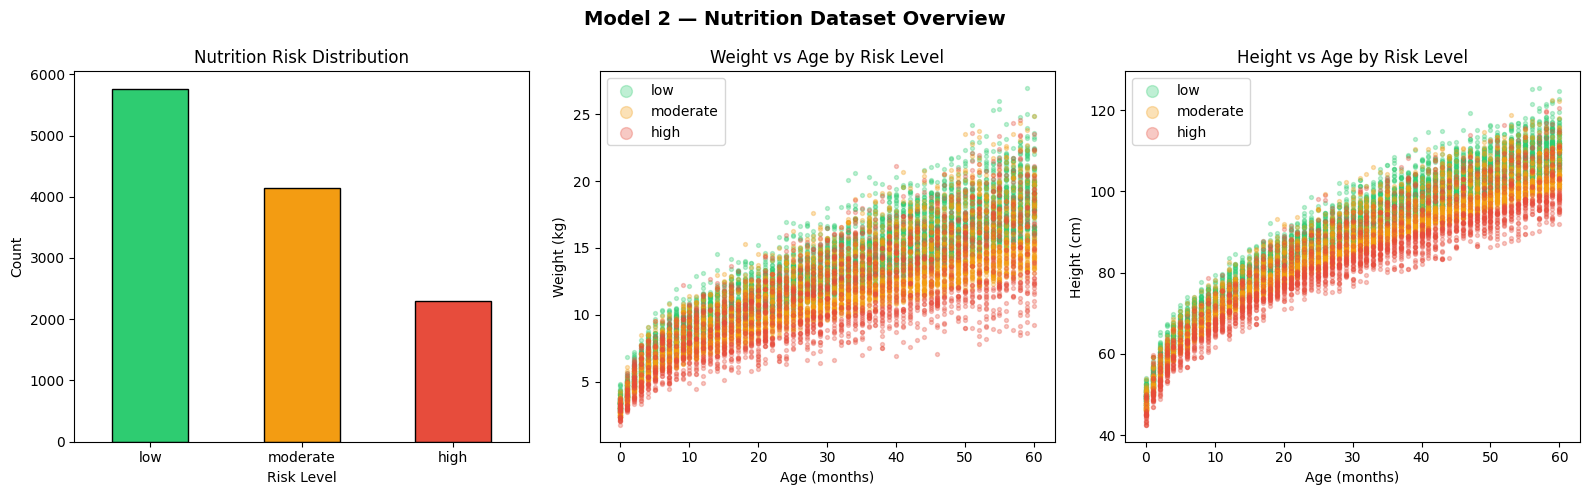

✅ Charts saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model 2 — Nutrition Dataset Overview', 
             fontsize=14, fontweight='bold')

# Chart 1: Nutrition risk distribution
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['nutrition_risk'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Nutrition Risk Distribution')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Weight vs Age by risk level
risk_colors = {'low':'#2ecc71', 'moderate':'#f39c12', 'high':'#e74c3c'}
for risk, color in risk_colors.items():
    subset = df[df['nutrition_risk'] == risk]
    axes[1].scatter(subset['age_months'], subset['weight_kg'],
                    c=color, label=risk, alpha=0.3, s=8)
axes[1].set_title('Weight vs Age by Risk Level')
axes[1].set_xlabel('Age (months)')
axes[1].set_ylabel('Weight (kg)')
axes[1].legend(markerscale=3)

# Chart 3: Height vs Age by risk level
for risk, color in risk_colors.items():
    subset = df[df['nutrition_risk'] == risk]
    axes[2].scatter(subset['age_months'], subset['height_cm'],
                    c=color, label=risk, alpha=0.3, s=8)
axes[2].set_title('Height vs Age by Risk Level')
axes[2].set_xlabel('Age (months)')
axes[2].set_ylabel('Height (cm)')
axes[2].legend(markerscale=3)

plt.tight_layout()
plt.savefig('../datasets/model2_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")

In [12]:
# Copy dataframe
df_model = df.copy()

# Encode gender: male=1, female=0
df_model['gender_encoded'] = (df_model['gender'] == 'male').astype(int)

# Encode nutrition risk labels
le = LabelEncoder()
df_model['risk_encoded'] = le.fit_transform(df_model['nutrition_risk'])

print("Nutrition risk encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {i} = {label}")

# Features
FEATURES = ['age_months', 'gender_encoded', 'weight_kg', 'height_cm']

X = df_model[FEATURES]
y = df_model['risk_encoded']

# Split BEFORE applying SMOTE
# Important: SMOTE is only applied to training data, never test data
indices = np.arange(len(df_model))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y)

X_train = X.iloc[idx_train]
X_test  = X.iloc[idx_test]
y_train = y.iloc[idx_train]
y_test  = y.iloc[idx_test]

print(f"\nBefore SMOTE:")
print(f"  Training set size: {len(X_train):,}")
for i, label in enumerate(le.classes_):
    count = (y_train == i).sum()
    print(f"  {label}: {count}")

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Convert to numpy arrays for StratifiedKFold indexing
X_train_balanced = np.array(X_train_balanced)
y_train_balanced = np.array(y_train_balanced)

print(f"\nAfter SMOTE:")
print(f"  Training set size: {len(X_train_balanced):,}")
for i, label in enumerate(le.classes_):
    count = (y_train_balanced == i).sum()
    print(f"  {label}: {count}")

print(f"\nTest set size: {len(X_test):,}")
print(f"\nFeatures: {FEATURES}")
print("✅ Data prepared and balanced!")

Nutrition risk encoding:
  0 = high
  1 = low
  2 = moderate

Before SMOTE:
  Training set size: 9,760
  high: 1838
  low: 4608
  moderate: 3314

After SMOTE:
  Training set size: 13,824
  high: 4608
  low: 4608
  moderate: 4608

Test set size: 2,440

Features: ['age_months', 'gender_encoded', 'weight_kg', 'height_cm']
✅ Data prepared and balanced!


In [6]:
print("Training Random Forest Classifier...")
print("(This may take 30-60 seconds)")

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE balanced data
clf.fit(X_train_balanced, y_train_balanced)

# Evaluate on original unbalanced test set
y_pred   = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Classifier trained!")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training Random Forest Classifier...
(This may take 30-60 seconds)

✅ Classifier trained!
Accuracy: 92.21%

Detailed Report:
              precision    recall  f1-score   support

        high       0.88      0.93      0.90       459
         low       0.97      0.94      0.96      1152
    moderate       0.88      0.89      0.89       829

    accuracy                           0.92      2440
   macro avg       0.91      0.92      0.92      2440
weighted avg       0.92      0.92      0.92      2440



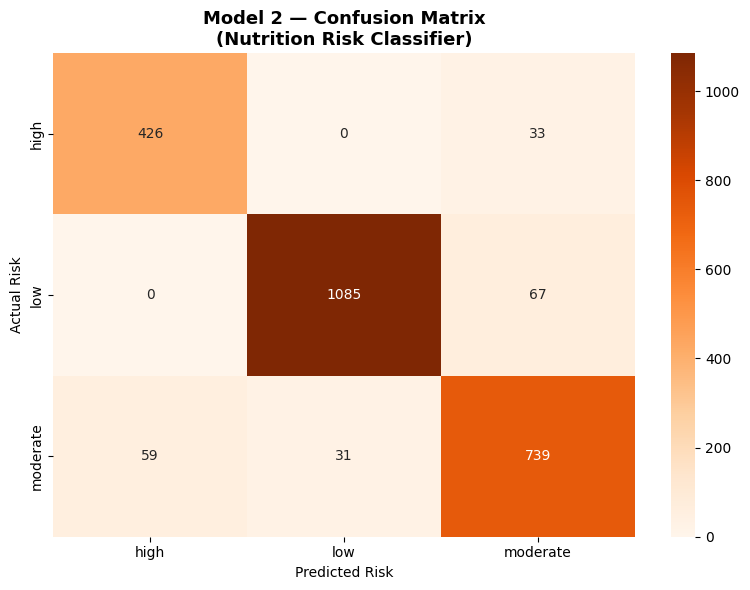

✅ Confusion matrix saved!


In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Model 2 — Confusion Matrix\n(Nutrition Risk Classifier)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.tight_layout()
plt.savefig('../datasets/model2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

In [13]:
from sklearn.model_selection import StratifiedKFold

print("Running 5-fold cross validation...")

# shuffle=True is essential because dataset is ordered by age
# Without shuffle, folds get different age ranges which causes bad scores
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
for fold, (train_idx, test_idx) in enumerate(skf.split(
        X_train_balanced, y_train_balanced)):
    X_f_train = X_train_balanced[train_idx]
    y_f_train = y_train_balanced[train_idx]
    X_f_test  = X_train_balanced[test_idx]
    y_f_test  = y_train_balanced[test_idx]
    
    fold_clf = RandomForestClassifier(
        n_estimators=100, max_depth=15,
        min_samples_split=5, random_state=42, n_jobs=-1)
    fold_clf.fit(X_f_train, y_f_train)
    score = accuracy_score(y_f_test, fold_clf.predict(X_f_test))
    cv_scores.append(score)

cv_scores = np.array(cv_scores)
print(f"\nCross Validation Results:")
print(f"Scores per fold: {[f'{s*100:.2f}%' for s in cv_scores]}")
print(f"Mean accuracy:   {cv_scores.mean()*100:.2f}%")
print(f"Std deviation:   {cv_scores.std()*100:.2f}%")

if cv_scores.mean() > 0.85:
    print("\n✅ Excellent! Model is performing very well.")
elif cv_scores.mean() > 0.75:
    print("\n✅ Good! Model is performing well.")
else:
    print("\n⚠️ Model may need improvement.")

Running 5-fold cross validation...

Cross Validation Results:
Scores per fold: ['94.68%', '93.60%', '94.21%', '94.65%', '93.70%']
Mean accuracy:   94.17%
Std deviation:   0.46%

✅ Excellent! Model is performing very well.


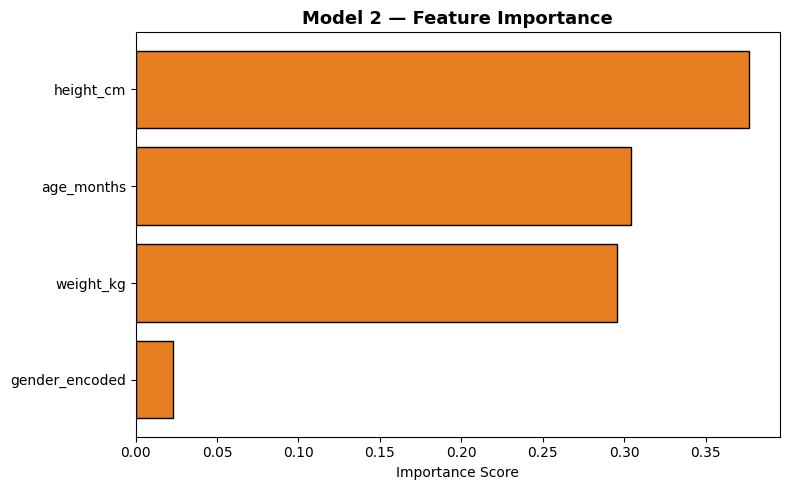


Feature importance ranking:
  height_cm                : 0.3768
  age_months               : 0.3044
  weight_kg                : 0.2956
  gender_encoded           : 0.0232


In [9]:
importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'],
         color='#e67e22', edgecolor='black')
plt.title('Model 2 — Feature Importance',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../datasets/model2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importance ranking:")
for _, row in importance_df.iloc[::-1].iterrows():
    print(f"  {row['feature']:25s}: {row['importance']:.4f}")

In [10]:
test_cases = [
    # Healthy child
    {'age_months':12, 'gender':'male',   
     'weight_kg':9.5,  'height_cm':75.0,
     'description':'Healthy 12mo boy'},
    # Moderate risk
    {'age_months':24, 'gender':'female', 
     'weight_kg':9.8,  'height_cm':81.0,
     'description':'Underweight 24mo girl'},
    # High risk
    {'age_months':18, 'gender':'male',   
     'weight_kg':7.5,  'height_cm':72.0,
     'description':'At-risk 18mo boy'},
]

print("=" * 50)
print("SAMPLE PREDICTIONS — MODEL 2")
print("=" * 50)

for case in test_cases:
    sample = pd.DataFrame([{
        'age_months'    : case['age_months'],
        'gender_encoded': 1 if case['gender']=='male' else 0,
        'weight_kg'     : case['weight_kg'],
        'height_cm'     : case['height_cm']
    }])

    pred_encoded  = clf.predict(sample)[0]
    pred_risk     = le.inverse_transform([pred_encoded])[0]
    probabilities = clf.predict_proba(sample)[0]

    print(f"\n{case['description']}")
    print(f"  Age: {case['age_months']} months | "
          f"Gender: {case['gender']} | "
          f"Weight: {case['weight_kg']} kg | "
          f"Height: {case['height_cm']} cm")
    print(f"  Predicted Risk: {pred_risk.upper()}")
    print(f"  Confidence: ", end="")
    for label, prob in zip(le.classes_, probabilities):
        print(f"{label}={prob*100:.1f}%", end="  ")
    print()

SAMPLE PREDICTIONS — MODEL 2

Healthy 12mo boy
  Age: 12 months | Gender: male | Weight: 9.5 kg | Height: 75.0 cm
  Predicted Risk: LOW
  Confidence: high=1.1%  low=81.5%  moderate=17.3%  

Underweight 24mo girl
  Age: 24 months | Gender: female | Weight: 9.8 kg | Height: 81.0 cm
  Predicted Risk: MODERATE
  Confidence: high=22.6%  low=4.3%  moderate=73.1%  

At-risk 18mo boy
  Age: 18 months | Gender: male | Weight: 7.5 kg | Height: 72.0 cm
  Predicted Risk: HIGH
  Confidence: high=92.5%  low=0.6%  moderate=6.9%  


In [11]:
os.makedirs('../ml_models', exist_ok=True)

# Save classifier
with open('../ml_models/model2_nutrition_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

# Save label encoder
with open('../ml_models/model2_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save feature list
with open('../ml_models/model2_features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("✅ All Model 2 files saved to ml_models/:")
print("  - model2_nutrition_classifier.pkl")
print("  - model2_label_encoder.pkl")
print("  - model2_features.pkl")

for fname in ['model2_nutrition_classifier.pkl',
              'model2_label_encoder.pkl',
              'model2_features.pkl']:
    size = os.path.getsize(f'../ml_models/{fname}')
    print(f"  {fname}: {size/1024:.1f} KB")

✅ All Model 2 files saved to ml_models/:
  - model2_nutrition_classifier.pkl
  - model2_label_encoder.pkl
  - model2_features.pkl
  model2_nutrition_classifier.pkl: 13450.1 KB
  model2_label_encoder.pkl: 0.3 KB
  model2_features.pkl: 0.1 KB


## Model 2 Training Complete ✅

### Model Saved
| File | Purpose |
|---|---|
| model2_nutrition_classifier.pkl | Classifies nutrition risk level |
| model2_label_encoder.pkl | Decodes numeric labels to text |
| model2_features.pkl | Feature list for Flask API |

### How Flask Will Use This
1. Load .pkl files when Flask starts
2. Accept age, gender, weight, height from frontend
3. Run classifier → return nutrition_risk (low/moderate/high)
4. Return result as JSON to React frontend